# S06 — SciPy, Pandas & Serialisation

**Python for Applied Physics** | Master in Applied Physics  
**Prerequisites:** S01–S05

---

## Learning objectives

By the end of this session you will be able to:

- Use `scipy.integrate`, `scipy.optimize`, `scipy.interpolate`, and `scipy.signal` for common physics tasks
- Fit experimental data with `curve_fit` and interpret the covariance output
- Compute spectrograms with `scipy.signal.spectrogram` and understand its parameters
- Organise tabular experimental data with Pandas `DataFrame`
- Serialise numerical data and metadata to JSON and HDF5
- Extend `shared/io.py` with reusable save/load functions

---

## Session map

| Block | Topic | Cells |
|-------|-------|-------|
| 1 | SciPy overview | 1–3 |
| 2 | Integration | 4–8 |
| 3 | Optimisation | 9–13 |
| 4 | Interpolation | 14–17 |
| 5 | Signal processing | 18–23 |
| 6 | Pandas | 24–29 |
| 7 | Serialisation | 30–34 |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
import pandas as pd
import h5py
import json

print(f"NumPy   {np.__version__}")
print(f"SciPy   {scipy.__version__}")
print(f"Pandas  {pd.__version__}")
print(f"h5py    {h5py.__version__}")

%matplotlib inline
plt.rcParams['figure.dpi'] = 100

NumPy   2.4.3
SciPy   1.17.1
Pandas  3.0.1
h5py    3.15.1


---
## Block 1 — SciPy overview

SciPy is a collection of scientific algorithms built on NumPy. Each submodule is independent — import only what you need.

| Submodule | Content |
|-----------|--------|
| `scipy.constants` | Physical constants (CODATA) |
| `scipy.integrate` | Quadrature, ODEs |
| `scipy.optimize` | Curve fitting, root finding, minimisation |
| `scipy.interpolate` | 1D/2D/nD interpolation |
| `scipy.signal` | Filtering, spectral analysis, peak detection |
| `scipy.linalg` | Linear algebra (extends `np.linalg`) |
| `scipy.fft` | FFT (faster than `np.fft` for large N) |
| `scipy.special` | Special functions (Bessel, Hermite, …) |

In [4]:
# --------------------------------------------------------------------------
# scipy.constants — exact CODATA values
# --------------------------------------------------------------------------

from scipy import constants

c   = constants.c          # speed of light (m/s)
h   = constants.h          # Planck constant (J·s)
hbar = constants.hbar      # reduced Planck (J·s)
kB  = constants.k          # Boltzmann (J/K)
e   = constants.e          # elementary charge (C)
ε0  = constants.epsilon_0  # vacuum permittivity (F/m)

print(f"c    = {c:.6e} m/s")
print(f"h    = {h:.6e} J·s")
print(f"ℏ    = {hbar:.6e} J·s")
print(f"kB   = {kB:.6e} J/K")
print(f"e    = {e:.6e} C")
print(f"ε₀   = {ε0:.6e} F/m")

# Photon energy at 800 nm
λ = 800e-9
E_photon = h * c / λ
print(f"\nPhoton energy at {λ*1e9:.0f} nm: {E_photon:.4e} J  =  {E_photon/e:.3f} eV")

c    = 2.997925e+08 m/s
h    = 6.626070e-34 J·s
ℏ    = 1.054572e-34 J·s
kB   = 1.380649e-23 J/K
e    = 1.602177e-19 C
ε₀   = 8.854188e-12 F/m

Photon energy at 800 nm: 2.4831e-19 J  =  1.550 eV


In [3]:
# --------------------------------------------------------------------------
# Import conventions used in this session
# --------------------------------------------------------------------------

from scipy import integrate, optimize, interpolate, signal

# Shared physics parameters used throughout
w0  = 500e-6    # beam radius (m)
P   = 1.0       # power (W)
τ   = 100e-15   # pulse duration (s)
λ0  = 800e-9    # wavelength (m)

# Time grid for pulse calculations
N   = 4096
dt  = 5e-15
t   = (np.arange(N) - N // 2) * dt
E_t = np.exp(-t**2 / (2 * τ**2))   # Gaussian envelope

print("Imports OK")

Imports OK


---
## Block 2 — Integration

`scipy.integrate.quad` computes a definite integral of a **scalar function** to high precision, returning both the result and an error estimate.

In [5]:
# --------------------------------------------------------------------------
# scipy.integrate.quad — 1D definite integral
# --------------------------------------------------------------------------

from scipy.integrate import quad

# 🔬 Total power from a Gaussian beam: P = 2π ∫₀^∞ I(r) r dr
I0 = 2 * P / (np.pi * w0**2)   # peak intensity

def integrand(r):
    return 2 * np.pi * r * I0 * np.exp(-2 * r**2 / w0**2)

P_calc, P_err = quad(integrand, 0, np.inf)

print(f"Integrated power : {P_calc:.8f} W")
print(f"Expected         : {P:.8f} W")
print(f"Absolute error   : {P_err:.2e} W")
print(f"Relative error   : {abs(P_calc - P)/P:.2e}")

Integrated power : 0.00000000 W
Expected         : 1.00000000 W
Absolute error   : 4.67e-14 W
Relative error   : 1.00e+00


In [6]:
# --------------------------------------------------------------------------
# 🔬 Physics Insight — pulse energy via quad
# --------------------------------------------------------------------------

# For a Gaussian pulse E(t) = exp(-t²/2τ²):
#   U = ∫ |E(t)|² dt = τ√(2π)

def pulse_intensity(t_val):
    return np.exp(-t_val**2 / τ**2)   # |E|² = exp(-t²/τ²)

U_quad, U_err = quad(pulse_intensity, -np.inf, np.inf)
U_analytic    = τ * np.sqrt(np.pi)

print(f"Pulse energy (quad)     : {U_quad:.6e} a.u.")
print(f"Pulse energy (analytic) : {U_analytic:.6e} a.u.")
print(f"Error estimate          : {U_err:.2e}")

Pulse energy (quad)     : 0.000000e+00 a.u.
Pulse energy (analytic) : 1.772454e-13 a.u.
Error estimate          : 0.00e+00


In [7]:
# --------------------------------------------------------------------------
# scipy.integrate.dblquad — 2D integration
# --------------------------------------------------------------------------

from scipy.integrate import dblquad

# Total power from 2D beam: P = ∫∫ I(x,y) dx dy
def I_2d(y, x):   # note: dblquad passes (inner_var, outer_var)
    return I0 * np.exp(-2 * (x**2 + y**2) / w0**2)

limit = 5 * w0
P_2d, P_2d_err = dblquad(I_2d, -limit, limit,
                          lambda x: -limit, lambda x: limit)

print(f"2D integrated power : {P_2d:.6f} W  (over ±5w₀ box)")
print(f"Expected (analytic) : {P:.6f} W")
print(f"Fraction captured   : {P_2d/P*100:.4f}%")

2D integrated power : 1.000000 W  (over ±5w₀ box)
Expected (analytic) : 1.000000 W
Fraction captured   : 100.0000%


⚠️ **Common Pitfall — `quad` vs `np.trapz`**

```python
# quad: works on a scalar Python function → high precision, slow for many calls
result, err = quad(f, a, b)

# np.trapz: works on pre-computed arrays → fast, precision limited by grid spacing
result = np.trapz(y_array, x_array)
```

Use `quad` when you need high precision on a smooth function.  
Use `np.trapz` (or `scipy.integrate.trapezoid`) when you already have discretised data.

In [ ]:
# Comparison: quad vs trapz on the pulse energy
U_trapz = np.trapz(np.abs(E_t)**2, t)
print(f"quad  : {U_quad:.8e}")
print(f"trapz : {U_trapz:.8e}")
print(f"Δ     : {abs(U_quad - U_trapz)/U_quad:.2e}  (relative)")

---
## Block 3 — Optimisation

Three tools cover most physics needs: `curve_fit` for data fitting, `brentq` for root finding, `minimize` for general minimisation.

In [8]:
# --------------------------------------------------------------------------
# scipy.optimize.curve_fit — nonlinear least squares
# --------------------------------------------------------------------------

from scipy.optimize import curve_fit

# Simulate a noisy beam profile measurement
rng      = np.random.default_rng(42) 
r_meas = np.linspace(-2e-3, 2e-3, 80)   # 80 radial points, ±2 mm
I_true = I0 * np.exp(-2 * r_meas**2 / w0**2)  # ideal Gaussian profile
noise  = rng.normal(0, 0.03 * I0, size=len(r_meas))         # Gaussian noise ~3% of I0
I_meas = I_true + noise                         # simulated "measurement"

# Model: Gaussian with 3 free parameters
def gaussian_beam(r, I_peak, w, r0):
    """Gaussian beam intensity model."""
    return I_peak * np.exp(-2 * (r - r0)**2 / w**2)

# Initial guess
p0 = [I_meas.max(), 0.5e-3, 0.0]  # [I_peak, w, r0]

popt, pcov = curve_fit(gaussian_beam, r_meas, I_meas, p0=p0)
perr       = np.sqrt(np.diag(pcov))   # 1σ parameter uncertainties

I_fit, w_fit, r0_fit = popt
σ_I, σ_w, σ_r0       = perr

print(f"I_peak = {I_fit:.3e} ± {σ_I:.1e} W/m²")
print(f"w      = {w_fit*1e6:.1f} ± {σ_w*1e6:.1f} µm  (true: {w0*1e6:.0f} µm)")
print(f"r₀     = {r0_fit*1e6:.2f} ± {σ_r0*1e6:.2f} µm")

I_peak = 2.545e+06 ± 2.4e+04 W/m²
w      = 506.0 ± 5.6 µm  (true: 500 µm)
r₀     = 1.10 ± 2.80 µm


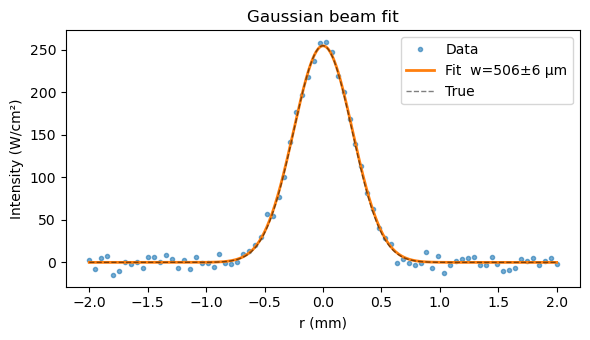

In [9]:
# Plot the fit
r_dense  = np.linspace(r_meas[0], r_meas[-1], 512)
I_fitted = gaussian_beam(r_dense, *popt)

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(r_meas*1e3, I_meas/1e4, 'o', ms=3, color='C0', alpha=0.6, label='Data')
ax.plot(r_dense*1e3, I_fitted/1e4, color='C1', lw=2,
        label=f'Fit  w={w_fit*1e6:.0f}±{σ_w*1e6:.0f} µm')
ax.plot(r_dense*1e3, gaussian_beam(r_dense, I0, w0, 0)/1e4,
        '--', color='k', lw=1, alpha=0.5, label='True')
ax.set_xlabel('r (mm)')
ax.set_ylabel('Intensity (W/cm²)')
ax.set_title('Gaussian beam fit')
ax.legend()
fig.tight_layout()
plt.show()

In [10]:
# --------------------------------------------------------------------------
# scipy.optimize.brentq — root finding
# --------------------------------------------------------------------------

from scipy.optimize import brentq

# 🔬 Find Brewster angle as root of r_p(θ) = 0
n1, n2 = 1.0, 1.5

def r_p(theta):
    """p-polarisation Fresnel reflection coefficient."""
    sin_t = n1 / n2 * np.sin(theta)
    if abs(sin_t) > 1:
        return 1.0   # TIR
    cos_t = np.sqrt(1 - sin_t**2)
    cos_i = np.cos(theta)
    return (n2 * cos_i - n1 * cos_t) / (n2 * cos_i + n1 * cos_t)

θ_B_numeric  = brentq(r_p, 0.01, np.pi/2 - 0.01)
θ_B_analytic = np.arctan(n2 / n1)

print(f"Brewster angle (brentq)   : {np.degrees(θ_B_numeric):.6f}°")
print(f"Brewster angle (analytic) : {np.degrees(θ_B_analytic):.6f}°")
print(f"Difference                : {abs(θ_B_numeric - θ_B_analytic):.2e} rad")

Brewster angle (brentq)   : 56.309932°
Brewster angle (analytic) : 56.309932°
Difference                : 0.00e+00 rad


In [ ]:
# --------------------------------------------------------------------------
# scipy.optimize.minimize — multivariate
# --------------------------------------------------------------------------

from scipy.optimize import minimize

# Find the beam waist position that maximises coupling into a single-mode fibre
# (toy model: coupling η ∝ exp(-(w_fibre - w_beam(z))² / w_fibre²))

w_fibre = 4e-6    # 4 µm fibre MFD/2
w0_beam = 3e-6
zR_beam = np.pi * w0_beam**2 / λ0

def neg_coupling(z_arr):
    z = z_arr[0]
    w_at_z = w0_beam * np.sqrt(1 + (z / zR_beam)**2)
    return -(np.exp(-(w_fibre - w_at_z)**2 / w_fibre**2))

result = minimize(neg_coupling, x0=[0.0], method='Nelder-Mead') # The Nelder-Mead method is an optimization algorithm 
                                                                # that finds the minimum of a function without using derivatives. 
                                                                # works on noisy or non-smooth functions
z_opt  = result.x[0]

print(f"Optimal coupling at z = {z_opt*1e6:.2f} µm")
print(f"Max coupling efficiency : {-result.fun:.4f}")

Optimal coupling at z = 31.25 µm
Max coupling efficiency : 1.0000


---
## Block 4 — Interpolation

linear  : RMS error = 0.0179
cubic   : RMS error = 0.0017


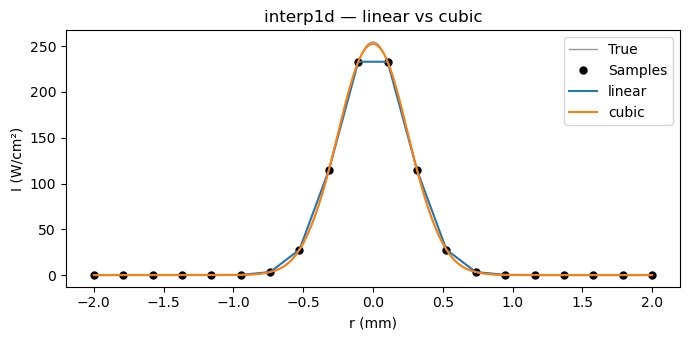

In [12]:
# --------------------------------------------------------------------------
# scipy.interpolate.interp1d — 1D interpolation
# --------------------------------------------------------------------------

from scipy.interpolate import interp1d

# Coarse beam profile (simulating a low-resolution camera)
r_coarse = np.linspace(-2e-3, 2e-3, 20)
I_coarse = I0 * np.exp(-2 * r_coarse**2 / w0**2)

# Interpolate to fine grid
r_fine = np.linspace(-2e-3, 2e-3, 512)

for kind in ['linear', 'cubic']:
    f_interp = interp1d(r_coarse, I_coarse, kind=kind)
    I_interp = f_interp(r_fine)
    I_true   = I0 * np.exp(-2 * r_fine**2 / w0**2)
    rms_err  = np.sqrt(np.mean((I_interp - I_true)**2)) / I0
    print(f"{kind:8s}: RMS error = {rms_err:.4f}")

# Plot comparison
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(r_fine*1e3,  I_true/1e4,  'k-',  lw=1, alpha=0.4, label='True')
ax.plot(r_coarse*1e3, I_coarse/1e4, 'ko', ms=5, label='Samples')
for kind, color in [('linear', 'C0'), ('cubic', 'C1')]:
    f_i = interp1d(r_coarse, I_coarse, kind=kind)
    ax.plot(r_fine*1e3, f_i(r_fine)/1e4, color=color, lw=1.5, label=kind)
ax.set_xlabel('r (mm)')
ax.set_ylabel('I (W/cm²)')
ax.set_title('interp1d — linear vs cubic')
ax.legend()
fig.tight_layout()
plt.show()

⚠️ **Common Pitfall — extrapolation**

By default `interp1d` raises a `ValueError` if you query outside the data range (`bounds_error=True`).  
If you set `bounds_error=False` you must also set `fill_value` — otherwise you get `NaN` silently.

```python
# Silent NaN outside range — dangerous
f = interp1d(x, y, bounds_error=False)

# Explicit: fill with edge values
f = interp1d(x, y, bounds_error=False, fill_value=(y[0], y[-1]))

# Explicit: allow extrapolation
f = interp1d(x, y, bounds_error=False, fill_value='extrapolate')
```

In [13]:
# --------------------------------------------------------------------------
# scipy.interpolate.RegularGridInterpolator — 2D interpolation
# --------------------------------------------------------------------------

from scipy.interpolate import RegularGridInterpolator

# Coarse 2D beam image (16×16 pixels)
N_coarse = 16
x_c = np.linspace(-3*w0, 3*w0, N_coarse)
y_c = np.linspace(-3*w0, 3*w0, N_coarse)
Xc, Yc = np.meshgrid(x_c, y_c, indexing='ij')   # indexing='ij' for RegularGridInterpolator
I_coarse_2d = I0 * np.exp(-2 * (Xc**2 + Yc**2) / w0**2)

# Build interpolator
rgi = RegularGridInterpolator((x_c, y_c), I_coarse_2d, method='cubic')

# Query on fine grid
N_fine = 128
x_f    = np.linspace(-3*w0, 3*w0, N_fine)
Xf, Yf = np.meshgrid(x_f, x_f, indexing='ij')
pts    = np.column_stack([Xf.ravel(), Yf.ravel()])
I_fine_2d = rgi(pts).reshape(N_fine, N_fine)

print(f"Coarse grid : {N_coarse}×{N_coarse}")
print(f"Fine grid   : {N_fine}×{N_fine}")
I_true_2d = I0 * np.exp(-2 * (Xf**2 + Yf**2) / w0**2)
print(f"RMS error   : {np.sqrt(np.mean((I_fine_2d - I_true_2d)**2))/I0:.4f}")

Coarse grid : 16×16
Fine grid   : 128×128
RMS error   : 0.0008


---
## Block 5 — Signal processing

Found 3 peaks:
  Peak 1: t = 2.99 ps, I = 1.023
  Peak 2: t = 8.99 ps, I = 0.650
  Peak 3: t = 15.03 ps, I = 0.841


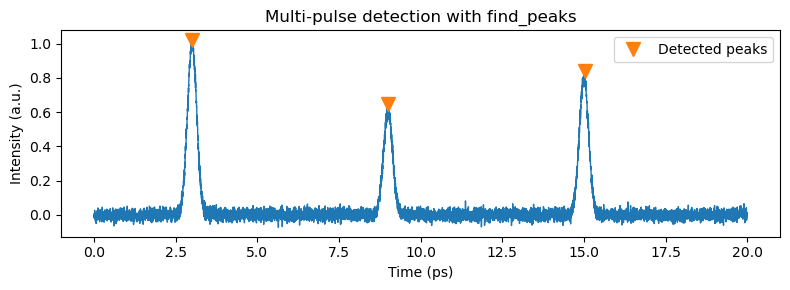

In [15]:
# --------------------------------------------------------------------------
# scipy.signal.find_peaks — peak detection
# --------------------------------------------------------------------------

from scipy import signal as sig

# Simulate a multi-pulse time trace (3 pulses with different energies)
rng     = np.random.default_rng(7)
t_trace = np.linspace(0, 20e-12, 8192)   # 0 to 20 ps
dt_tr   = t_trace[1] - t_trace[0]

pulse_times    = [3e-12, 9e-12, 15e-12]
pulse_energies = [1.0, 0.6, 0.8]
τ_pulse        = 200e-15

I_trace = np.zeros_like(t_trace)
for t0, A in zip(pulse_times, pulse_energies):
    I_trace += A * np.exp(-((t_trace - t0) / τ_pulse)**2)
I_trace += rng.normal(0, 0.02, size=len(t_trace))   # noise

# Find peaks
peaks, props = sig.find_peaks(
    I_trace,
    height=0.3,        # minimum peak height
    distance=int(1e-12 / dt_tr),   # minimum separation: 1 ps
    prominence=0.2,    # minimum prominence above surroundings
)

print(f"Found {len(peaks)} peaks:")
for i, pk in enumerate(peaks):
    print(f"  Peak {i+1}: t = {t_trace[pk]*1e12:.2f} ps, I = {I_trace[pk]:.3f}")

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(t_trace*1e12, I_trace, lw=1, color='C0')
ax.plot(t_trace[peaks]*1e12, I_trace[peaks], 'v', ms=10, color='C1', label='Detected peaks')
ax.set_xlabel('Time (ps)')
ax.set_ylabel('Intensity (a.u.)')
ax.set_title('Multi-pulse detection with find_peaks')
ax.legend()
fig.tight_layout()
plt.show()

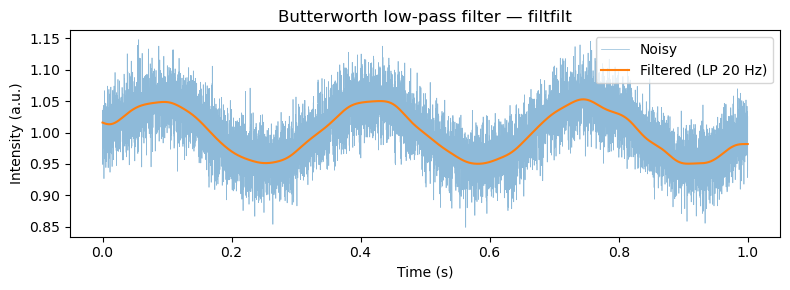

In [ ]:
# --------------------------------------------------------------------------
# scipy.signal.butter + filtfilt — low-pass filtering
# --------------------------------------------------------------------------

# Simulate laser intensity noise: slow drift + fast noise
t_noise  = np.linspace(0, 1.0, 10000)   # 1 second
fs       = 1 / (t_noise[1] - t_noise[0])   # sampling rate (Hz)
slow     = 0.05 * np.sin(2 * np.pi * 3 * t_noise)    # 3 Hz drift
fast     = rng.normal(0, 0.03, size=len(t_noise))     # broadband noise
I_noisy  = 1.0 + slow + fast

# Design a 4th-order Butterworth low-pass filter at 20 Hz


f_cutoff = 20   # Hz
b, a = sig.butter(
    4,                    # filter order: higher = sharper roll-off at cutoff
    f_cutoff / (fs / 2),  # normalized cutoff freq: must be in (0, 1);
                          # fs/2 is the Nyquist frequency
    btype='low'           # low-pass: keeps frequencies below f_cutoff
)
# b, a: numerator and denominator coefficients of the transfer function
# filtfilt applies the filter twice (forward + backward),
# cancelling any phase shift — unlike lfilter, which shifts
# the signal in time and distorts pulse arrival times/peak positions

I_filtered = sig.filtfilt(b, a, I_noisy)   # zero-phase filtering


fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(t_noise, I_noisy,    lw=0.5, color='C0', alpha=0.5, label='Noisy')
ax.plot(t_noise, I_filtered, lw=1.5, color='C1', label='Filtered (LP 20 Hz)')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Intensity (a.u.)')
ax.set_title('Butterworth low-pass filter — filtfilt')
ax.legend()
fig.tight_layout()
plt.show()

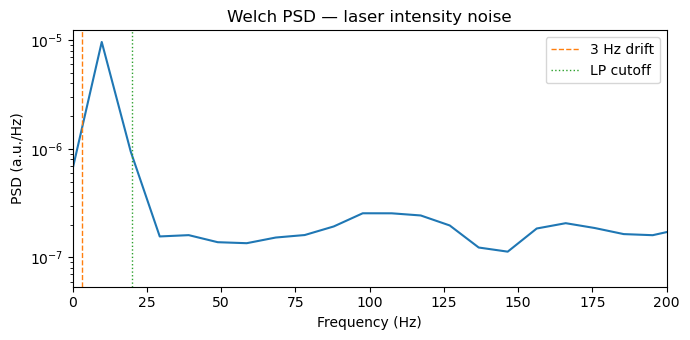

In [20]:
# --------------------------------------------------------------------------
# scipy.signal.welch — power spectral density
# --------------------------------------------------------------------------

f_welch, Pxx = sig.welch(I_noisy, fs=fs, nperseg=1024)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.semilogy(f_welch, Pxx, color='C0')
ax.axvline(3, color='C1', ls='--', lw=1, label='3 Hz drift')
ax.axvline(f_cutoff, color='C2', ls=':', lw=1, label='LP cutoff')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('PSD (a.u./Hz)')
ax.set_title('Welch PSD — laser intensity noise')
ax.legend()
ax.set_xlim(0, 200)
fig.tight_layout()
plt.show()

In [36]:
# --------------------------------------------------------------------------
# scipy.signal.spectrogram — STFT done properly
#
# In S05 we built an STFT by hand (sliding window + FFT in a loop).
# scipy.signal.spectrogram does the same thing, optimised.
# --------------------------------------------------------------------------

# Rebuild the chirped pulse from S05 Ex7
N_sg  = 8192
dt_sg = 2e-14
τ_sg  = 50e-15
GDD   = 2000e-27

t_sg  = (np.arange(N_sg) - N_sg // 2) * dt_sg
E_sg  = np.exp(-t_sg**2 / (2 * τ_sg**2))

freq_sg = np.fft.fftshift(np.fft.fftfreq(N_sg, d=dt_sg))
ω_sg    = 2 * np.pi * freq_sg
E_f_sg  = np.fft.fftshift(np.fft.fft(E_sg))
E_f_ch  = E_f_sg * np.exp(0.5j * GDD * ω_sg**2)
E_chirp = np.fft.ifft(np.fft.ifftshift(E_f_ch)).real

# scipy.signal.spectrogram returns (frequencies, times, Sxx)
# nperseg controls frequency resolution; noverlap controls time resolution
fs_sg = 1 / dt_sg
f_sg, t_out, Sxx = sig.spectrogram(
    E_chirp,
    fs        = fs_sg,
    window    = ('gaussian', 128) ,        # (window type, std in samples)
    nperseg   = 512,               # FFT window length
    noverlap  = 480,               # overlap between windows
    scaling   = 'spectrum',
)

# t_out is relative to start of array — shift to match our centred t axis
t_centre = t_sg[0] + t_out

print(f"Sxx shape  : {Sxx.shape}  (n_freq × n_time)")
print(f"Freq bins  : {len(f_sg)}  (0 to {f_sg[-1]/1e12:.1f} THz)")
print(f"Time steps : {len(t_out)}")

# 💡 Pro Tip: note the axis order — Sxx[freq_idx, time_idx]
# pcolormesh expects (x, y, Z) = (time, freq, Sxx.T)

Sxx shape  : (257, 241)  (n_freq × n_time)
Freq bins  : 257  (0 to 25.0 THz)
Time steps : 241


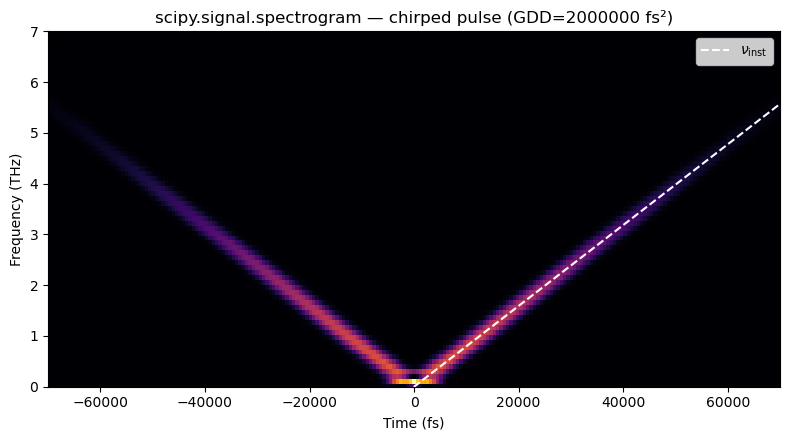

In [42]:
# Plot the spectrogram
freq_mask = f_sg < 15e12   # show up to 15 THz

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.pcolormesh(
    t_centre * 1e15,
    f_sg[freq_mask] / 1e12,
    Sxx[freq_mask, :],
    cmap='inferno', shading='auto'
)

# Expected instantaneous frequency
Δt_TL    = 2 * np.sqrt(2 * np.log(2)) * τ_sg
Δt_chirp = Δt_TL * np.sqrt(1 + (GDD / τ_sg**2)**2)
t_plot   = np.linspace(-Δt_chirp, Δt_chirp, 200)
ν_inst   = t_plot / (2 * np.pi * GDD)
ax.plot(t_plot*1e15, ν_inst/1e12, 'w--', lw=1.5, label=r'$\nu_{\rm inst}$')

ax.set_xlabel('Time (fs)')
ax.set_ylabel('Frequency (THz)')
ax.set_title(f'scipy.signal.spectrogram — chirped pulse (GDD={GDD*1e30:.0f} fs²)')
ax.set_xlim(-70e3, 70e3)
ax.set_ylim(0, 7)
ax.legend()
fig.tight_layout()
plt.show()


💡 **Pro Tip — `spectrogram` parameter trade-offs**

| Parameter | Effect |
|-----------|--------|
| `nperseg` ↑ | Better frequency resolution, worse time resolution |
| `nperseg` ↓ | Better time resolution, worse frequency resolution |
| `noverlap` ↑ | Smoother time axis, more computation |
| `window` | Gaussian → good for Gabor transform; Hann → good for general audio |

This is the **time–frequency uncertainty principle** applied to numerical computation.

---
## Block 6 — Pandas

Pandas `DataFrame` is the standard tool for tabular experimental data — shot logs, parameter sweeps, measurement tables.

In [43]:
# --------------------------------------------------------------------------
# Creating a DataFrame — laser shot log
# --------------------------------------------------------------------------

rng = np.random.default_rng(99)

n_shots = 60
channels = ['800nm', '1030nm', '1550nm']

shot_log = pd.DataFrame({
    'shot_id'   : np.arange(1, n_shots + 1),
    'channel'   : rng.choice(channels, size=n_shots),
    'energy_uJ' : rng.normal(50, 2, size=n_shots).round(2),
    'duration_fs': rng.normal(100, 5, size=n_shots).round(1),
    'pointing_urad': rng.normal(0, 15, size=n_shots).round(1),
})

# Introduce a few NaN values (missing measurements)
shot_log.loc[rng.choice(n_shots, 4, replace=False), 'duration_fs'] = np.nan

print(shot_log.head(8))
print(f"\nShape: {shot_log.shape}")
print(f"dtypes:\n{shot_log.dtypes}")

   shot_id channel  energy_uJ  duration_fs  pointing_urad
0        1  1550nm      51.93         98.9            2.7
1        2  1030nm      51.50        100.6           -1.9
2        3  1550nm      49.91        100.3          -10.0
3        4  1030nm      48.71        106.0           24.7
4        5   800nm      53.92        102.8           -8.3
5        6  1030nm      51.38         95.7           -0.4
6        7  1550nm      46.86        100.4           -0.0
7        8  1550nm      51.68         99.9          -32.9

Shape: (60, 5)
dtypes:
shot_id            int64
channel              str
energy_uJ        float64
duration_fs      float64
pointing_urad    float64
dtype: object


In [44]:
# --------------------------------------------------------------------------
# Indexing: .iloc (positional) vs .loc (label-based)
# --------------------------------------------------------------------------

# .iloc — integer position
print("First 3 rows (iloc):")
print(shot_log.iloc[:3])

# .loc — label / boolean mask
high_energy = shot_log.loc[shot_log['energy_uJ'] > 52]
print(f"\nHigh-energy shots (>52 µJ): {len(high_energy)}")

# Select specific columns
print("\nEnergy and duration (first 5):")
print(shot_log[['energy_uJ', 'duration_fs']].head())

First 3 rows (iloc):
   shot_id channel  energy_uJ  duration_fs  pointing_urad
0        1  1550nm      51.93         98.9            2.7
1        2  1030nm      51.50        100.6           -1.9
2        3  1550nm      49.91        100.3          -10.0

High-energy shots (>52 µJ): 9

Energy and duration (first 5):
   energy_uJ  duration_fs
0      51.93         98.9
1      51.50        100.6
2      49.91        100.3
3      48.71        106.0
4      53.92        102.8


In [45]:
# --------------------------------------------------------------------------
# Groupby + aggregation
# --------------------------------------------------------------------------

summary = shot_log.groupby('channel').agg(
    n_shots      = ('shot_id',     'count'),
    mean_energy  = ('energy_uJ',   'mean'),
    std_energy   = ('energy_uJ',   'std'),
    mean_duration= ('duration_fs', 'mean'),   # NaN rows automatically skipped
).round(2)

print(summary)

# RMS pointing per channel
rms_pointing = shot_log.groupby('channel')['pointing_urad'].apply(
    lambda x: np.sqrt(np.mean(x**2))
).round(2)
print(f"\nRMS pointing per channel (µrad):")
print(rms_pointing)

         n_shots  mean_energy  std_energy  mean_duration
channel                                                 
1030nm        25        50.18        1.64         100.99
1550nm        19        49.76        1.88          97.52
800nm         16        50.92        2.07          99.37

RMS pointing per channel (µrad):
channel
1030nm    15.61
1550nm    16.05
800nm     13.70
Name: pointing_urad, dtype: float64


In [46]:
# --------------------------------------------------------------------------
# CSV I/O
# --------------------------------------------------------------------------

import tempfile, os

with tempfile.TemporaryDirectory() as tmp:
    path_csv = os.path.join(tmp, 'shot_log.csv')
    shot_log.to_csv(path_csv, index=False)

    df_loaded = pd.read_csv(path_csv)
    print(f"Written and re-read: {df_loaded.shape}")
    print(df_loaded.head(3))

Written and re-read: (60, 5)
   shot_id channel  energy_uJ  duration_fs  pointing_urad
0        1  1550nm      51.93         98.9            2.7
1        2  1030nm      51.50        100.6           -1.9
2        3  1550nm      49.91        100.3          -10.0


⚠️ **Common Pitfall — chained indexing**

```python
# WRONG: may or may not modify the original DataFrame
df[df['channel'] == '800nm']['energy_uJ'] = 0   # ← SettingWithCopyWarning

# RIGHT: use .loc with a boolean mask
df.loc[df['channel'] == '800nm', 'energy_uJ'] = 0
```

Chained indexing (`df[...][...]`) creates an intermediate copy and the assignment may not propagate. Always use `.loc[row_mask, column_name]` for in-place modifications.

---
## Block 7 — Serialisation

Two formats cover most physics data needs:

| Format | Best for | Library |
|--------|----------|--------|
| JSON | Config files, metadata, small structured data | `json` (stdlib) |
| HDF5 | Large numerical arrays + metadata, hierarchical data | `h5py` |

In [ ]:
# --------------------------------------------------------------------------
# JSON — metadata and configuration
# --------------------------------------------------------------------------

import json

# Experiment metadata
metadata = {
    'experiment'  : 'pulse_characterisation',
    'date'        : '2026-04-01',
    'operator'    : 'luis',
    'laser'       : {
        'wavelength_nm' : 800,
        'rep_rate_kHz'  : 1.0,
        'pulse_energy_uJ': 50.0,
    },
    'notes'       : 'Transform-limited pulse, no GDD compensation'
}

# Serialise to string
json_str = json.dumps(metadata, indent=2)
print(json_str[:300])

# Round-trip
meta_back = json.loads(json_str)
assert meta_back['laser']['wavelength_nm'] == 800

# Write to file
with tempfile.TemporaryDirectory() as tmp:
    path_json = os.path.join(tmp, 'metadata.json')
    with open(path_json, 'w') as f:
        json.dump(metadata, f, indent=2)
    with open(path_json) as f:
        meta_file = json.load(f)
    print(f"\nJSON file round-trip OK: {meta_file['experiment']}")

In [ ]:
# --------------------------------------------------------------------------
# HDF5 with h5py — arrays + metadata in one file
# --------------------------------------------------------------------------

import h5py

# Build a realistic pulse dataset
N_h5  = 2048
dt_h5 = 5e-15
τ_h5  = 100e-15
t_h5  = (np.arange(N_h5) - N_h5 // 2) * dt_h5
E_h5  = np.exp(-t_h5**2 / (2 * τ_h5**2)) * np.exp(1j * 2*np.pi * 375e12 * t_h5)

with tempfile.TemporaryDirectory() as tmp:
    path_h5 = os.path.join(tmp, 'pulse.h5')

    # Write
    with h5py.File(path_h5, 'w') as f:
        # Groups act like folders
        grp = f.create_group('pulse')

        # Datasets
        grp.create_dataset('t',   data=t_h5,          compression='gzip')
        grp.create_dataset('E_t', data=E_h5,          compression='gzip')
        grp.create_dataset('I_t', data=np.abs(E_h5)**2)

        # Attributes (metadata attached to dataset or group)
        grp.attrs['wavelength_nm']  = 800.0
        grp.attrs['tau_fs']         = τ_h5 * 1e15
        grp.attrs['dt_fs']          = dt_h5 * 1e15
        grp.attrs['description']    = 'Gaussian pulse, transform-limited'
        grp['t'].attrs['units']     = 's'
        grp['E_t'].attrs['units']   = 'a.u.'

    # Read back
    with h5py.File(path_h5, 'r') as f:
        print("HDF5 structure:")
        f.visit(lambda name: print(f"  {name}"))

        grp   = f['pulse']
        t_rd  = grp['t'][:]
        E_rd  = grp['E_t'][:]
        attrs = dict(grp.attrs)

    print(f"\nAttributes: {attrs}")
    print(f"t shape   : {t_rd.shape}")
    print(f"Round-trip: {np.allclose(t_rd, t_h5) and np.allclose(E_rd, E_h5)}")

In [ ]:
# --------------------------------------------------------------------------
# shared/io.py — reusable save/load functions
# --------------------------------------------------------------------------

def save_pulse_hdf5(
    path: str,
    t: np.ndarray,
    E_t: np.ndarray,
    **metadata,
) -> None:
    """
    Save a pulse field and metadata to an HDF5 file.

    Parameters
    ----------
    path : str
        Output file path (e.g. 'data/pulse_001.h5').
    t : np.ndarray
        Time array (s).
    E_t : np.ndarray
        Complex electric field envelope.
    **metadata
        Arbitrary keyword arguments stored as HDF5 attributes.
        Values must be scalars or strings.
    """
    with h5py.File(path, 'w') as f:
        grp = f.create_group('pulse')
        grp.create_dataset('t',   data=t,              compression='gzip')
        grp.create_dataset('E_t', data=E_t,            compression='gzip')
        grp.create_dataset('I_t', data=np.abs(E_t)**2)
        grp['t'].attrs['units']   = 's'
        grp['E_t'].attrs['units'] = 'a.u.'
        for key, value in metadata.items():
            grp.attrs[key] = value


def load_pulse_hdf5(path: str) -> dict:
    """
    Load a pulse dataset from an HDF5 file.

    Returns
    -------
    dict with keys 't', 'E_t', 'I_t', and all stored metadata attributes.
    """
    with h5py.File(path, 'r') as f:
        grp  = f['pulse']
        data = {
            't'  : grp['t'][:],
            'E_t': grp['E_t'][:],
            'I_t': grp['I_t'][:],
        }
        data.update(dict(grp.attrs))
    return data


# Self-test
with tempfile.TemporaryDirectory() as tmp:
    path_test = os.path.join(tmp, 'test_pulse.h5')
    save_pulse_hdf5(path_test, t_h5, E_h5,
                    wavelength_nm=800.0,
                    tau_fs=τ_h5*1e15,
                    description='Test pulse')
    result = load_pulse_hdf5(path_test)

assert np.allclose(result['t'],   t_h5)
assert np.allclose(result['E_t'], E_h5)
assert result['wavelength_nm'] == 800.0
print("save_pulse_hdf5 / load_pulse_hdf5 ✓")
print(f"Keys returned: {list(result.keys())}")

💡 **Pro Tip — when to use HDF5 vs `.npz` vs CSV**

| Format | Strengths | Limitations |
|--------|-----------|-------------|
| `.npy/.npz` | Fast, simple, NumPy native | No metadata, no hierarchy, NumPy only |
| CSV | Human-readable, universal | Slow for large arrays, no metadata |
| HDF5 | Arrays + metadata + hierarchy + compression | Requires `h5py`, binary format |
| JSON | Human-readable metadata | Numbers only, no arrays |

**Rule of thumb:** use HDF5 for any dataset that includes both arrays and metadata, or that other tools (MATLAB, LabVIEW, Origin) need to read.

---
## Summary

| Task | Key call |
|------|----------|
| Physical constants | `from scipy import constants; constants.c` |
| 1D integral | `integrate.quad(f, a, b)` |
| 2D integral | `integrate.dblquad(f, xa, xb, ya, yb)` |
| Curve fit | `optimize.curve_fit(model, x, y, p0=)` → `popt, pcov` |
| Root finding | `optimize.brentq(f, a, b)` |
| Minimisation | `optimize.minimize(f, x0, method=)` |
| 1D interpolation | `interpolate.interp1d(x, y, kind='cubic')` |
| 2D interpolation | `interpolate.RegularGridInterpolator((x, y), Z)` |
| Peak detection | `signal.find_peaks(x, height=, distance=, prominence=)` |
| Filtering | `signal.butter(N, Wn)` + `signal.filtfilt(b, a, x)` |
| Welch PSD | `signal.welch(x, fs=, nperseg=)` |
| Spectrogram | `signal.spectrogram(x, fs=, nperseg=, noverlap=)` → `(f, t, Sxx)` |
| DataFrame | `pd.DataFrame({...})`, `.loc`, `.iloc`, `.groupby().agg()` |
| CSV I/O | `df.to_csv(path)`, `pd.read_csv(path)` |
| JSON | `json.dump/load`, `json.dumps/loads` |
| HDF5 write | `h5py.File(path, 'w')`, `.create_dataset`, `.attrs` |
| HDF5 read | `h5py.File(path, 'r')`, `dataset[:]`, `dict(group.attrs)` |

**`shared/` addition:** `shared/io.py` ← `save_pulse_hdf5`, `load_pulse_hdf5`

**Next: S07 — Object-Oriented Programming**